# Telco Customer Churn — Feature Engineering

**Goal:** Transform raw columns into features that help the model learn
*business signals*, not just raw values — without letting the test set
influence any decision it shouldn't.

Features are built in five stages:
1. Load and sanity-check the cleaned data from `01_eda.ipynb`
2. Construct **deterministic** engineered features (fixed rules, no dataset statistics)
3. Encode fixed-rule categorical variables (Yes/No → 0/1)
4. **Split into train/test** — before anything that learns from the data
5. Fit data-dependent transformations (median threshold, one-hot encoding) on
   the training set only, then apply them to test

> **Design note on leakage:**
> Two things in the original version of this notebook computed a statistic
> over the *entire* dataset before splitting: the median used for
> `above_median_spend`, and one-hot encoding via `pd.get_dummies` on the
> full frame. Both let the test set influence its own features. This
> version fixes that by moving the split earlier and fitting both steps
> on training data only, using `sklearn`'s `ColumnTransformer` /
> `OneHotEncoder` so the fitted encoder can also be reused cleanly at
> inference time.
>
> Everything else below — `tenure_bucket`, `spend_per_tenure`,
> `num_services`, `multiple_lines`, `has_security_or_support`,
> `electronic_check`, and the binary Yes/No mappings — uses fixed rules
> or per-row arithmetic, not dataset-level statistics, so computing them
> before the split is safe regardless of order.


## 1. Setup

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
import joblib

sns.set_theme(style="whitegrid")
%matplotlib inline


## 2. Load and validate cleaned data

We load from `telco_cleaned.csv` produced by notebook 01.
A quick sanity check confirms shape, dtypes, and no unexpected nulls.


In [16]:
df = pd.read_csv('../data/telco_cleaned.csv')
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print()
print(df.dtypes)


Shape: 7,032 rows × 22 columns

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
Churn_Binary          int64
dtype: object


In [17]:
# Confirm no nulls made it through
assert df.isnull().sum().sum() == 0, "Unexpected nulls found — check notebook 01"
print("No nulls. All clear.")


No nulls. All clear.


## 3. Construct deterministic engineered features

Each feature below is motivated by a specific business insight from the EDA,
and each is computed from fixed rules or per-row arithmetic — none of them
use a dataset-level statistic (median, mean, fitted encoding), so it's safe
to build these before the train/test split.

`above_median_spend` — which *does* need a dataset statistic — is deliberately
**not** built here. It's built after the split, using only the training
median (see Section 5).


In [18]:
# ── Feature 1: Tenure buckets ────────────────────────────────────────────────
# Rationale: Churn risk is highly non-linear with tenure.
# New customers (0–6 months) churn at ~50%; loyal customers (4+ years) barely at all.
# Bucketing captures this threshold effect without assuming linearity.
# Bin edges are fixed constants, not derived from the data, so this is safe pre-split.
df['tenure_bucket'] = pd.cut(
    df['tenure'],
    bins=[0, 6, 12, 24, 48, 72],
    labels=['0-6mo', '6-12mo', '1-2yr', '2-4yr', '4+yr'],
    include_lowest=True,
)

# ── Feature 2: Spend per month of tenure ─────────────────────────────────────
# Rationale: Normalises TotalCharges by tenure to get average monthly spend.
# More stable than TotalCharges alone (which is highly collinear with tenure).
# +1 avoids divide-by-zero for tenure=0 customers. Pure per-row arithmetic — safe.
df['spend_per_tenure'] = df['TotalCharges'] / (df['tenure'] + 1)

# ── Feature 3: Number of internet add-on services ────────────────────────────
# Rationale: Customers with more add-ons are "stickier" — switching costs
# are higher. From EDA, more services → lower churn rate.
#
# IMPORTANT DESIGN NOTE: earlier version of this feature counted 'Yes' across
# 8 columns including PhoneService/MultipleLines. That conflated two very
# different customers at count=0/1: someone with internet who declined every
# add-on, vs. someone with NO internet service at all (whose add-on columns
# are all 'No internet service', which also reads as 0). That confound broke
# monotonicity — churn rate actually went 0.44 → 0.21 → 0.33 → 0.36 as the
# count increased, because the count=1 bucket was 70% no-internet customers.
#
# Fix: restrict the count to the 6 genuinely internet-dependent add-ons, and
# only compute it for customers who actually have internet. No-internet
# customers get 0 by convention, but that's now safe to interpret because
# the model also sees an explicit `InternetService_No` flag (from the OHE
# step below) — the two features together let the model distinguish
# "has internet, chose nothing" from "has no internet."
internet_addon_cols = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
]
has_internet = df['InternetService'] != 'No'
df['num_services'] = 0
df.loc[has_internet, 'num_services'] = (
    df.loc[has_internet, internet_addon_cols] == 'Yes'
).sum(axis=1)

# ── Feature 3b: Multiple lines flag ───────────────────────────────────────────
# Rationale: MultipleLines used to be folded into the old num_services count.
# Since that count is now restricted to internet add-ons only, MultipleLines
# needs its own explicit feature so its signal isn't silently dropped later.
df['multiple_lines'] = (df['MultipleLines'] == 'Yes').astype(int)

# ── Feature 4: Has security or support service ───────────────────────────────
# Rationale: "Commitment" services like OnlineSecurity and TechSupport
# signal that a customer has invested in the platform beyond basic connectivity.
df['has_security_or_support'] = (
    (df['OnlineSecurity'] == 'Yes') | (df['TechSupport'] == 'Yes')
).astype(int)

# ── Feature 5: Electronic check flag ─────────────────────────────────────────
# Rationale: EDA showed electronic check users churn at ~45% vs ~15–20% for
# automatic payment methods. Isolating this as a binary flag gives it
# explicit weight; it will NOT be re-encoded in the OHE step below.
df['electronic_check'] = (df['PaymentMethod'] == 'Electronic check').astype(int)

print("Engineered features preview:")
eng_cols = [
    'tenure_bucket', 'spend_per_tenure',
    'num_services', 'multiple_lines', 'has_security_or_support', 'electronic_check',
]
df[eng_cols].head(8)


Engineered features preview:


,tenure_bucket,spend_per_tenure,num_services,multiple_lines,has_security_or_support,electronic_check
0,0-6mo,14.925000,1,0,0,1
1,2-4yr,53.985714,2,0,1,0
2,0-6mo,36.050000,2,0,1,0
3,2-4yr,40.016304,3,0,1,0
4,0-6mo,50.550000,0,0,0,1
5,6-12mo,91.166667,3,1,0,1
6,1-2yr,84.756522,2,1,0,0
7,6-12mo,27.445455,1,0,1,0


### 3.1 Validate engineered features against churn

Quick churn-rate check on each new feature to confirm it carries signal.

**Note:** this check runs on the full dataset, before the split. That's fine
here because it's purely descriptive/exploratory — it doesn't feed into any
automated feature selection or model fitting. If you find yourself dropping
or keeping a feature *because* of what you see here, do that reasoning
explicitly in writing (as the interpretation cell below asks you to), so it's
clear this was a documented judgment call rather than the model quietly
overfitting to a full-dataset pattern.


In [19]:
print("Churn rate by tenure bucket:")
print(df.groupby('tenure_bucket', observed=True)['Churn_Binary'].mean().round(3))
print()
print("Churn rate by number of internet add-on services (internet customers only):")
print(df.loc[df['InternetService'] != 'No']
        .groupby('num_services')['Churn_Binary'].mean().round(3))
print()
print("Churn rate: no internet service vs. has internet")
print(df.assign(has_internet=(df['InternetService'] != 'No').astype(int))
        .groupby('has_internet')['Churn_Binary'].mean().round(3))
print()
print("Churn rate: multiple_lines")
print(df.groupby('multiple_lines')['Churn_Binary'].mean().round(3))
print()
print("Churn rate: has_security_or_support")
print(df.groupby('has_security_or_support')['Churn_Binary'].mean().round(3))
print()
print("Churn rate: electronic_check")
print(df.groupby('electronic_check')['Churn_Binary'].mean().round(3))


Churn rate by tenure bucket:
tenure_bucket
0-6mo     0.533
6-12mo    0.359
1-2yr     0.287
2-4yr     0.204
4+yr      0.095
Name: Churn_Binary, dtype: float64

Churn rate by number of internet add-on services (internet customers only):
num_services
0    0.522
1    0.458
2    0.358
3    0.274
4    0.224
5    0.125
6    0.053
Name: Churn_Binary, dtype: float64

Churn rate: no internet service vs. has internet
has_internet
0    0.074
1    0.319
Name: Churn_Binary, dtype: float64

Churn rate: multiple_lines
multiple_lines
0    0.251
1    0.286
Name: Churn_Binary, dtype: float64

Churn rate: has_security_or_support
has_security_or_support
0    0.335
1    0.171
Name: Churn_Binary, dtype: float64

Churn rate: electronic_check
electronic_check
0    0.171
1    0.453
Name: Churn_Binary, dtype: float64


✍️ **YOUR INTERPRETATION HERE**

- Which engineered feature looks like the strongest signal here, and how do you know (compare the spread of churn rates within each feature)?
- The num_services fix — walk through *why* the original count was misleading and what changed. This is worth documenting since it was a real bug, not just a style choice.
- multiple_lines has a much smaller churn-rate spread than the other features — what does that suggest about whether it'll be a useful predictor?


## 4. Encode fixed-rule categorical variables

**Strategy:**
- **Binary columns** (Yes/No): map directly to 0/1 — a fixed rule, not a
  fitted transformation, so safe to apply before or after the split
- **`PaymentMethod`**: we already captured the key signal via `electronic_check`,
  so we exclude it from OHE to avoid redundancy
- Multi-class columns (`Contract`, `InternetService`, `tenure_bucket`) are
  **not** encoded here — that's a fitted transformation and happens after
  the split, in Section 6


In [20]:
# ── Binary Yes/No columns → 0/1 ─────────────────────────────────────────────
# NOTE: gender and PhoneService are intentionally NOT encoded here. The EDA
# notebook's Cramér's V ranking (01_eda.ipynb, Section 8.1) found both have
# essentially zero association with churn (V = 0.008 and 0.011 -- noise
# level), and explicitly recommended dropping them. Both are removed
# entirely in the cleanup step below rather than encoded and carried
# forward, keeping the final feature set consistent with that finding.
binary_map = {
    'Partner':          ('Yes', 'No'),
    'Dependents':       ('Yes', 'No'),
    'PhoneService':     ('Yes', 'No'),
    'PaperlessBilling': ('Yes', 'No'),
}
for col, (pos, _) in binary_map.items():
    df[col] = (df[col] == pos).astype(int)

print("Binary encoding done.")
df[['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']].head(4)


Binary encoding done.


,Partner,Dependents,PhoneService,PaperlessBilling
0,1,0,0,1
1,0,0,1,0
2,0,0,1,1
3,0,0,0,0


## 5. Train/test split

This happens **before** any transformation that learns a statistic from the
data (the spend median, the one-hot encoding). Everything after this point
fits only on `df_train` and is applied unchanged to `df_test` — the test set
is not touched again until final model evaluation in notebook 3.

Stratified on `Churn_Binary` so both sets keep the same churn rate.


In [21]:
df_train, df_test = train_test_split(
    df,
    test_size=0.2,
    stratify=df['Churn_Binary'],
    random_state=42,
)

print(f"Train: {df_train.shape[0]:,} rows  (churn rate: {df_train['Churn_Binary'].mean():.1%})")
print(f"Test:  {df_test.shape[0]:,} rows  (churn rate: {df_test['Churn_Binary'].mean():.1%})")


Train: 5,625 rows  (churn rate: 26.6%)
Test:  1,407 rows  (churn rate: 26.6%)


## 6. Fit data-dependent transformations on training data only

Two things need a statistic learned from the data:

1. **`above_median_spend`** — the median `MonthlyCharges` threshold. Computed
   from `df_train` only, then applied as a fixed cutoff to both train and test.
2. **One-hot encoding** — `Contract`, `InternetService`, `tenure_bucket`. Fit
   with `OneHotEncoder` on `df_train` only (`handle_unknown='ignore'` so any
   category not seen in training — e.g. at real inference time — doesn't
   crash the pipeline), then applied to both.


In [22]:
# ── above_median_spend: threshold learned from train only ───────────────────
median_charge_train = df_train['MonthlyCharges'].median()
print(f"Median MonthlyCharges (train only): ${median_charge_train:.2f}")

for split_df in (df_train, df_test):
    split_df['above_median_spend'] = (split_df['MonthlyCharges'] > median_charge_train).astype(int)


Median MonthlyCharges (train only): $70.60


In [23]:
# ── Drop columns no longer needed ────────────────────────────────────────────
# - customerID: identifier, not a feature
# - Churn: raw string version; Churn_Binary is our target
# - PaymentMethod: signal captured by electronic_check
# - MultipleLines: signal captured by multiple_lines
# - Raw service string columns: signal captured by num_services /
#   has_security_or_support; keeping them as strings would require further
#   encoding and introduces redundancy with engineered features
# - gender, PhoneService: near-zero Cramér's V association with churn
#   (0.008 and 0.011 -- see 01_eda.ipynb Section 8.1), dropped rather than
#   encoded, per that notebook's own recommendation

to_drop = [
    'customerID', 'Churn', 'PaymentMethod', 'MultipleLines',
    'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'gender', 'PhoneService',
]
to_drop = [c for c in to_drop if c in df_train.columns]

df_train = df_train.drop(columns=to_drop)
df_test = df_test.drop(columns=to_drop)

print(f"Train shape after cleanup: {df_train.shape}")
print(f"Test shape after cleanup:  {df_test.shape}")


Train shape after cleanup: (5625, 17)
Test shape after cleanup:  (1407, 17)


In [24]:
# ── One-hot encode multi-class columns, fit on train only ───────────────────
ohe_cols = ['Contract', 'InternetService', 'tenure_bucket']

X_train_raw = df_train.drop(columns=['Churn_Binary'])
X_test_raw = df_test.drop(columns=['Churn_Binary'])
y_train = df_train['Churn_Binary']
y_test = df_test['Churn_Binary']

preprocessor = ColumnTransformer(
    transformers=[
        ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), ohe_cols),
    ],
    remainder='passthrough',
    verbose_feature_names_out=False,
)
preprocessor.set_output(transform='pandas')

X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print()
print("New OHE columns:")
print([c for c in X_train.columns if any(c.startswith(p + '_') for p in ohe_cols)])


X_train: (5625, 21)
X_test:  (1407, 21)

New OHE columns:
['Contract_One year', 'Contract_Two year', 'InternetService_Fiber optic', 'InternetService_No', 'tenure_bucket_1-2yr', 'tenure_bucket_2-4yr', 'tenure_bucket_4+yr', 'tenure_bucket_6-12mo']


## 7. Final feature matrix check

Before saving, we confirm — separately for train and test:
- No leftover string/object columns
- No nulls
- Target column is present and correctly distributed


In [25]:
for name, X, y in [('Train', X_train, y_train), ('Test', X_test, y_test)]:
    obj_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
    null_count = X.isnull().sum().sum()
    print(f"--- {name} ---")
    print(f"  Non-numeric columns: {obj_cols if obj_cols else 'none'}")
    print(f"  Total nulls: {null_count}")
    print(f"  Churn rate: {y.mean():.1%}  (n={len(y):,})")
    print()


--- Train ---
  Non-numeric columns: none
  Total nulls: 0
  Churn rate: 26.6%  (n=5,625)

--- Test ---
  Non-numeric columns: none
  Total nulls: 0
  Churn rate: 26.6%  (n=1,407)



## 8. Feature correlation with churn (train set only)

Exploratory only — computed on the training set so nothing about the test
set's distribution leaks into how we interpret or discuss the features.


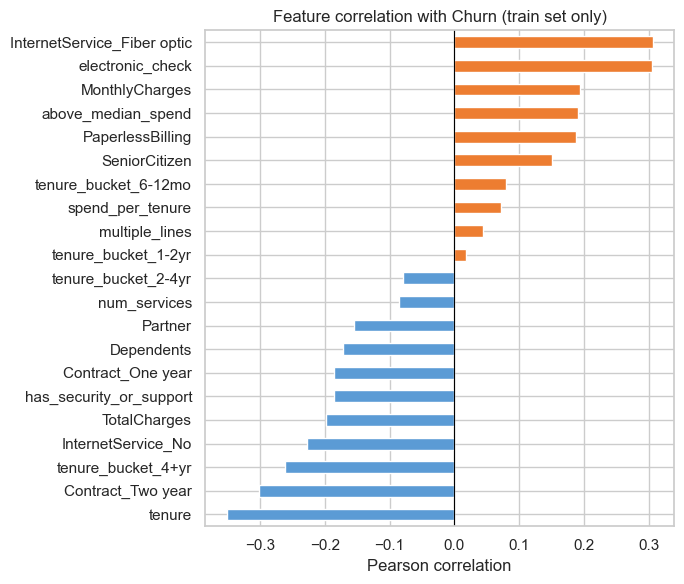

In [26]:
train_with_target = X_train.copy()
train_with_target['Churn_Binary'] = y_train.values

corr = train_with_target.corr(numeric_only=True)['Churn_Binary'].drop('Churn_Binary').sort_values()

fig, ax = plt.subplots(figsize=(7, 6))
colors = ['#ED7D31' if v > 0 else '#5B9BD5' for v in corr]
corr.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature correlation with Churn (train set only)')
ax.set_xlabel('Pearson correlation')
plt.tight_layout()
plt.savefig('../data/plots/feature_correlation.png', dpi=150)
plt.show()


**What to look for:**
- `Contract_Two year` and `Contract_One year` should be strongly *negative* — long contracts retain customers
- `tenure` should be strongly negative
- `electronic_check`, `above_median_spend` should be positive
- If `spend_per_tenure` and `MonthlyCharges` have nearly identical correlations,
  consider dropping one before modelling (collinearity)


✍️ **YOUR INTERPRETATION HERE**

- Now that you've run the correlation, which of the 'what to look for' predictions above actually held up, and which didn't?
- Did spend_per_tenure and MonthlyCharges turn out to be collinear? What did you decide to do about it, if anything?
- Any surprises — a feature you expected to matter that didn't, or vice versa?


## 9. Save feature matrices and the fitted preprocessor

Saves train and test feature matrices **separately** (never re-concatenated),
plus the fitted `ColumnTransformer` itself — so notebook 3 (or a real
inference pipeline) can reuse the exact same fitted encoding rather than
re-deriving it.


In [27]:
X_train.assign(Churn_Binary=y_train.values).to_csv('../data/telco_features_train.csv', index=False)
X_test.assign(Churn_Binary=y_test.values).to_csv('../data/telco_features_test.csv', index=False)
joblib.dump(preprocessor, '../data/fitted_preprocessor.joblib')

print(f"Saved telco_features_train.csv  ({X_train.shape[0]:,} rows × {X_train.shape[1] + 1} columns)")
print(f"Saved telco_features_test.csv   ({X_test.shape[0]:,} rows × {X_test.shape[1] + 1} columns)")
print("Saved fitted_preprocessor.joblib")
print("Ready for 03_modeling_and_evaluation.ipynb")


Saved telco_features_train.csv  (5,625 rows × 22 columns)
Saved telco_features_test.csv   (1,407 rows × 22 columns)
Saved fitted_preprocessor.joblib
Ready for 03_modeling_and_evaluation.ipynb
